In [ ]:
!PYTHONPATH=src python scripts/2_test/evaluate_jores.py \
    --checkpoint_path results/models/checkpoints/stage2_batchsize_probe/size_/stage2/best.pt \
    --input_tsv metadata/modelling_data_tamsACR.tsv \

Using device: cpu
{
  "n_samples": 33300,
  "per_condition": {
    "cold": {
      "mse": 0.8651975393295288,
      "rmse": 0.9301599536260035,
      "mae": 0.7096660733222961,
      "pearsonr": 0.6752281229978714,
      "spearmanr": 0.6862052992944164
    },
    "dark": {
      "mse": 1.0712186098098755,
      "rmse": 1.034996912947027,
      "mae": 0.7748556137084961,
      "pearsonr": 0.7460433282350634,
      "spearmanr": 0.7677643962160664
    },
    "light": {
      "mse": 0.8165218830108643,
      "rmse": 0.903616004180351,
      "mae": 0.677728533744812,
      "pearsonr": 0.7298853960160548,
      "spearmanr": 0.7477265248910108
    },
    "warm": {
      "mse": 0.7030798196792603,
      "rmse": 0.8384985507913895,
      "mae": 0.6331651210784912,
      "pearsonr": 0.7237236222506821,
      "spearmanr": 0.7463152559851597
    },
    "maize": {
      "mse": 0.7108848094940186,
      "rmse": 0.8431398516818064,
      "mae": 0.6200757622718811,
      "pearsonr": 0.5164471180074677

In [6]:
!PYTHONPATH=src python scripts/2_test/plot_jores_scatter.py \
    --predictions_csv results/models/checkpoints/stage2_batchsize_probe/size_/stage2/best_test_eval/test_predictions.csv \
    --condition_order light dark warm cold maize \
    --model_name AlphaGenome

Saved plot to /grid/koo/home/kachu/projects/alphagenome-encoder-ft/results/models/checkpoints/stage2_batchsize_probe/size_/stage2/best_test_eval/y_vs_y_pred_by_condition.png


In [1]:
import sys
sys.path.insert(0, "scripts/0_preprocess")

from data_prep import acr_excel_to_tsv
metadata_path = "/grid/koo/home/kachu/projects/alphagenome-encoder-ft/metadata"
excel_file = metadata_path + "/media-3.xlsx"
output_file = metadata_path + "/acr_sequence_library.tsv"

data = acr_excel_to_tsv(excel_file, output_file)

Wrote 365593 rows to /grid/koo/home/kachu/projects/alphagenome-encoder-ft/metadata/acr_sequence_library.tsv


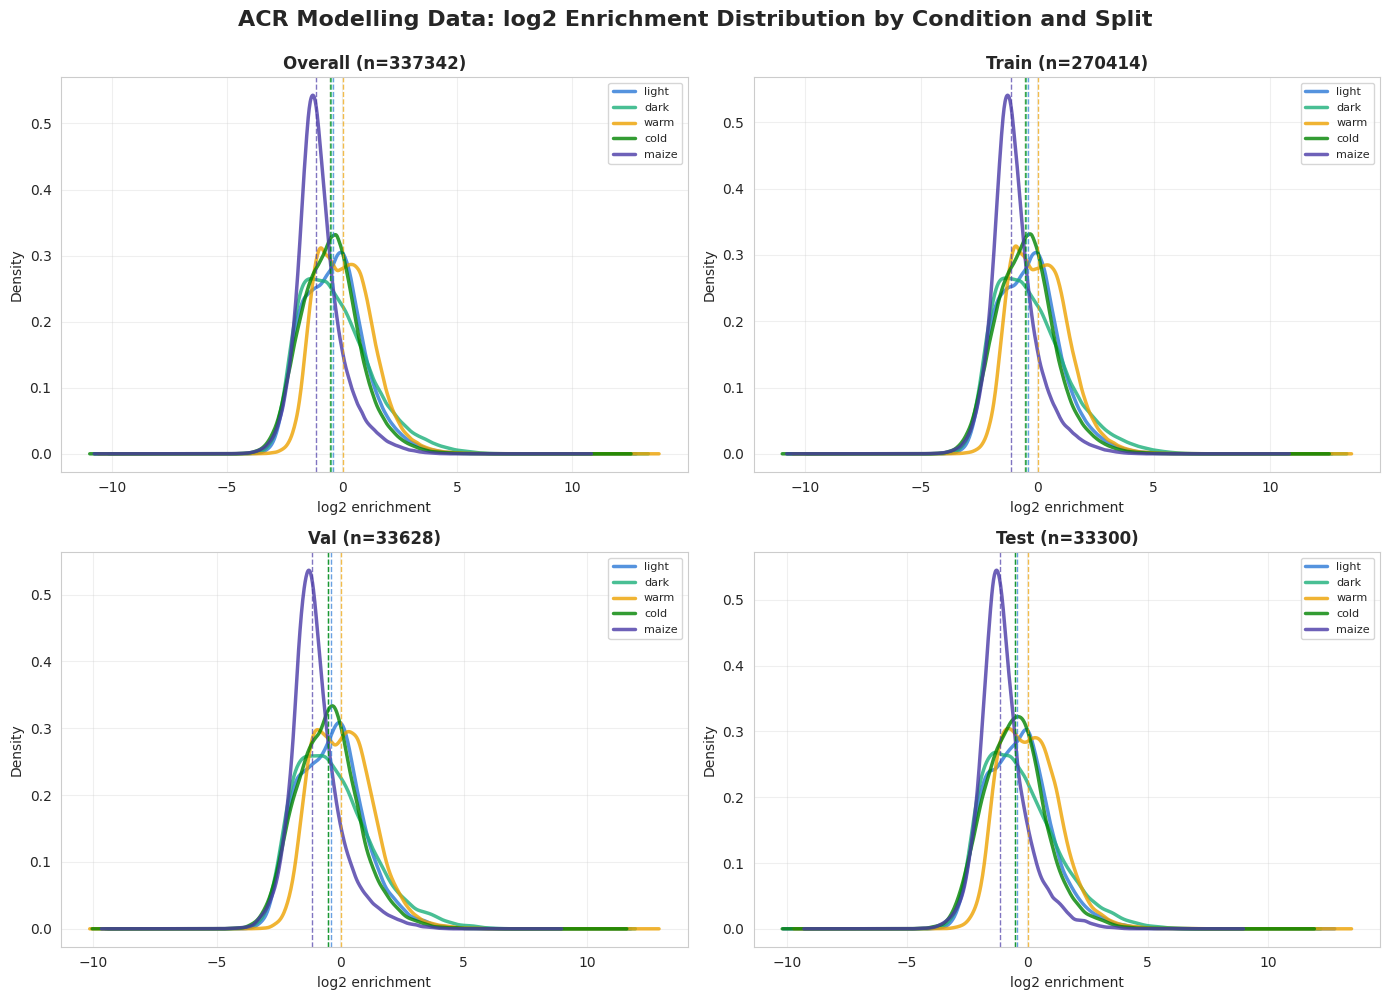

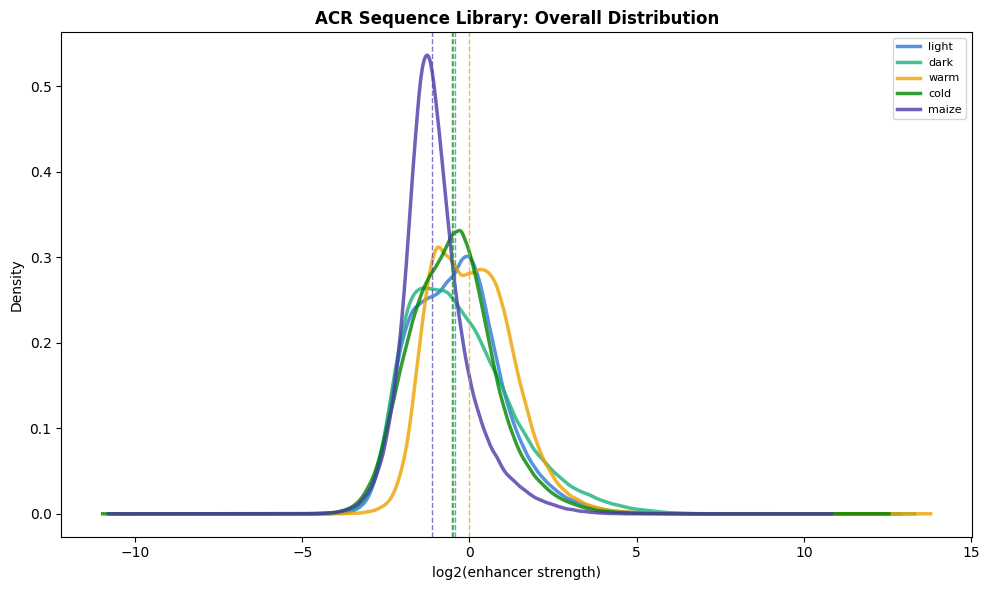

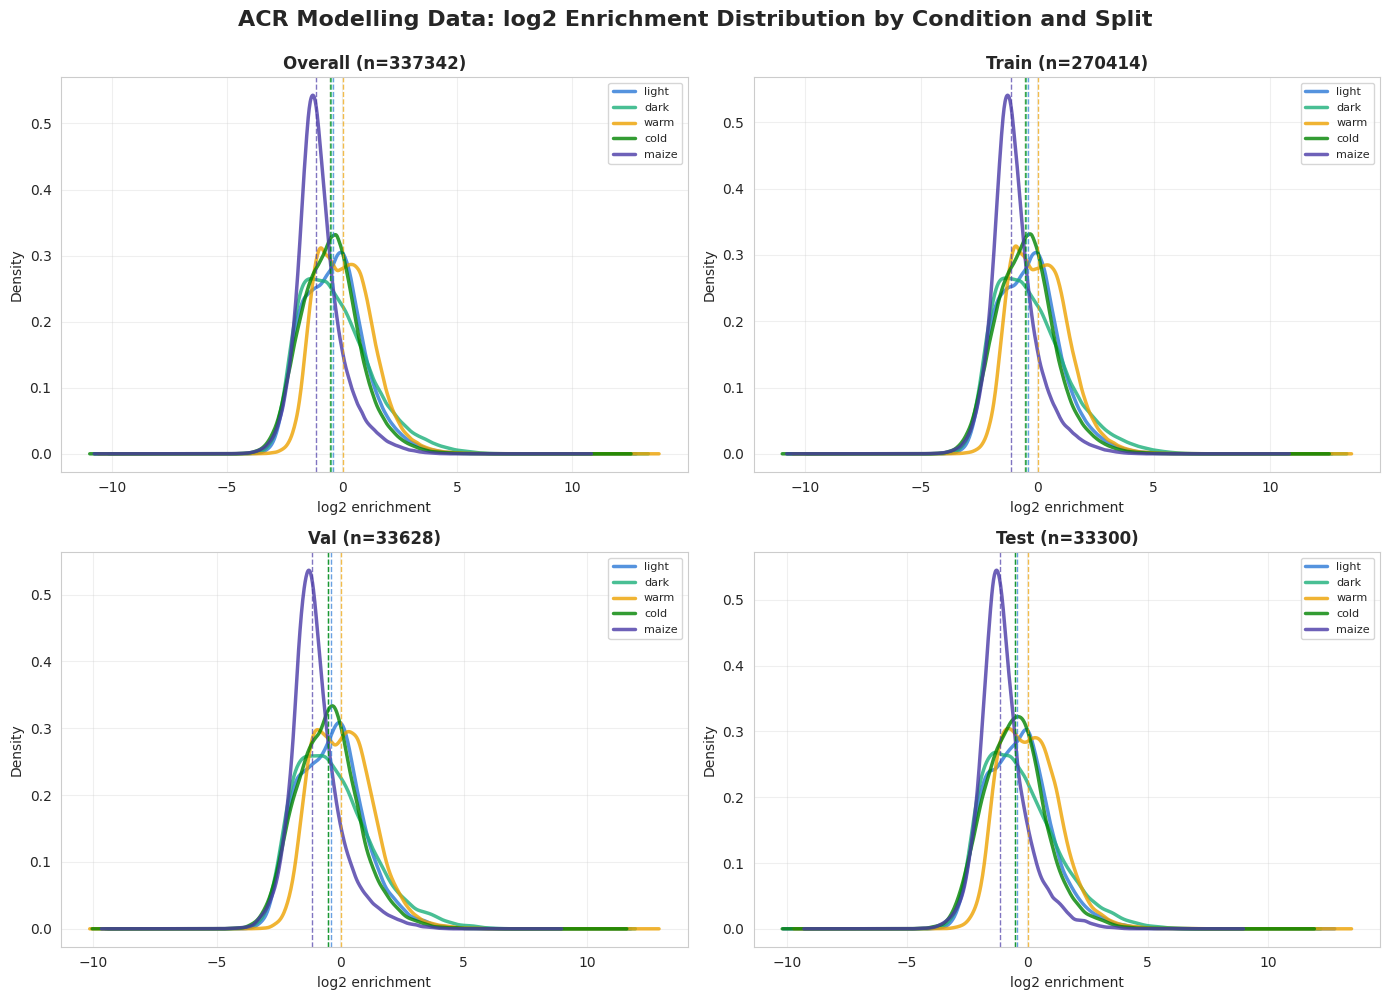

In [2]:
from data_prep import plot_acr_overall_distribution, plot_acr_distribution_by_split
import pandas as pd


acr_data = pd.read_csv(metadata_path + "/acr_sequence_library.tsv", sep='\t')
plot_acr_overall_distribution(acr_data, output_path="results/plots/acr_overall_distribution.png")

# ACR modelling data: overall + train/val/test split distributions (5 conditions each)
acr_split_data = pd.read_csv(metadata_path + "/modelling_data_tamsACR.tsv", sep='\t')
plot_acr_distribution_by_split(acr_split_data, output_path="results/plots/acr_distribution_by_split.png")

Largest difference for enrichment_cold and enrichment_warm is Zm-24742_fwd at -4.672624600612174
Largest difference for enrichment_dark and enrichment_light is At-37911_fwd at 8.018851679375354


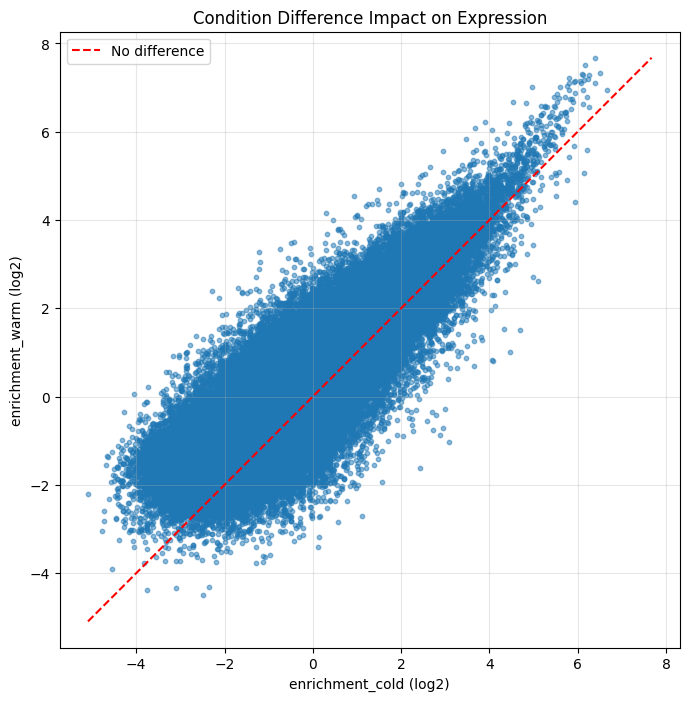

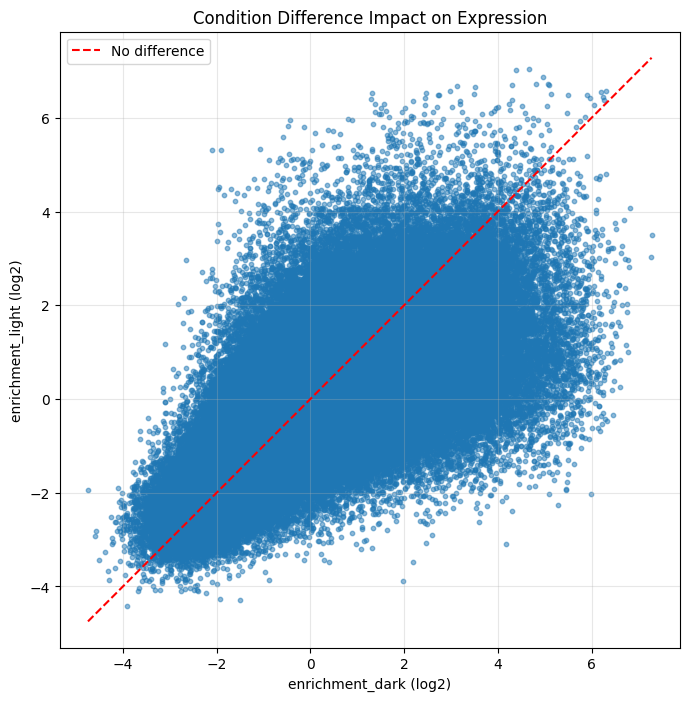

In [1]:
import sys
sys.path.insert(0, "scripts/0_preprocess")
from data_prep import find_condition_diff
data ="/grid/koo/home/kachu/projects/alphagenome-encoder-ft/metadata/modelling_data_tamsACR.tsv" 

find_condition_diff(data, 'enrichment_cold', 'enrichment_warm',  "results/plots/cold_vs_warm.png")
find_condition_diff(data, 'enrichment_dark', 'enrichment_light', "results/plots/dark_vs_light.png")

In [1]:
import sys
sys.path.insert(0, "scripts/0_preprocess")

from data_prep import compute_pseudocount_log2_from_readcounts

metadata_path = "/grid/koo/home/kachu/projects/alphagenome-encoder-ft/metadata"
full_readcount_file = metadata_path + "/RNA DNA ReadCount All.xlsx"
sequences_file = metadata_path + "/Supplementary Data Set 1.xlsx"

df = compute_pseudocount_log2_from_readcounts(full_readcount_file, sequences_file, metadata_path + "/full_pseudocount_log2.tsv", pseudocount=1)

Step 1 - recovered DNA library totals:
  DNA-1: 3,320,127.0
  DNA-2: 3,095,787.0
  DNA-3: 3,435,500.0
Step 1 - recovered RNA library totals:
  Leaf-1: 8,332,762.0
  Leaf-2: 11,318,885.0
  Leaf-3: 10,272,091.0
  MG-1: 9,010,340.0
  MG-2: 9,269,028.0
  MG-3: 8,789,335.0
  Br-1: 8,957,339.0
  Br-2: 7,833,359.0
  Br-3: 9,428,668.0
  RR-1: 8,648,844.0
  RR-2: 9,364,379.0
  RR-3: 8,337,439.0

Step 2 - pooled DNA total (sum of 3 reps): 9,851,414.0
Step 2 - pooled DNA counts (per fragment), preview:
0    496
1    335
2    487
3    937
4    814
dtype: int64

Step 2 - pooled Leaf total (sum of 3 reps): 29,923,738.0
Step 2 - pooled Leaf counts (per fragment), preview:
0    2045
1    1046
2    1654
3    2218
4    1318
dtype: int64

Step 2 - pooled MG total (sum of 3 reps): 27,068,703.0
Step 2 - pooled MG counts (per fragment), preview:
0       0
1    1116
2    2119
3    1600
4     688
dtype: int64

Step 2 - pooled Br total (sum of 3 reps): 26,219,366.0
Step 2 - pooled Br counts (per fragment), pre

Step 1 - recovered DNA library totals:
  DNA-1: 3,320,127.0
  DNA-2: 3,095,787.0
  DNA-3: 3,435,500.0
Step 1 - recovered RNA library totals:
  Leaf-1: 8,332,762.0
  Leaf-2: 11,318,885.0
  Leaf-3: 10,272,091.0
  MG-1: 9,010,340.0
  MG-2: 9,269,028.0
  MG-3: 8,789,335.0
  Br-1: 8,957,339.0
  Br-2: 7,833,359.0
  Br-3: 9,428,668.0
  RR-1: 8,648,844.0
  RR-2: 9,364,379.0
  RR-3: 8,337,439.0

Step 2 - pooled DNA total (sum of 3 reps): 9,851,414.0
Step 2 - pooled DNA counts (per fragment), preview:
0    496
1    335
2    487
3    937
4    814
dtype: int64

Step 2 - pooled Leaf total (sum of 3 reps): 29,923,738.0
Step 2 - pooled Leaf counts (per fragment), preview:
0    2045
1    1046
2    1654
3    2218
4    1318
dtype: int64

Step 2 - pooled MG total (sum of 3 reps): 27,068,703.0
Step 2 - pooled MG counts (per fragment), preview:
0       0
1    1116
2    2119
3    1600
4     688
dtype: int64

Step 2 - pooled Br total (sum of 3 reps): 26,219,366.0
Step 2 - pooled Br counts (per fragment), pre

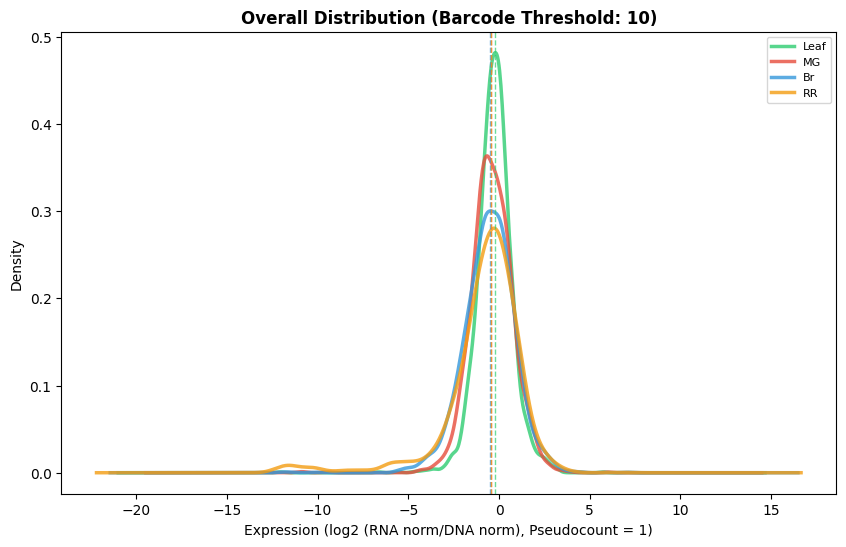

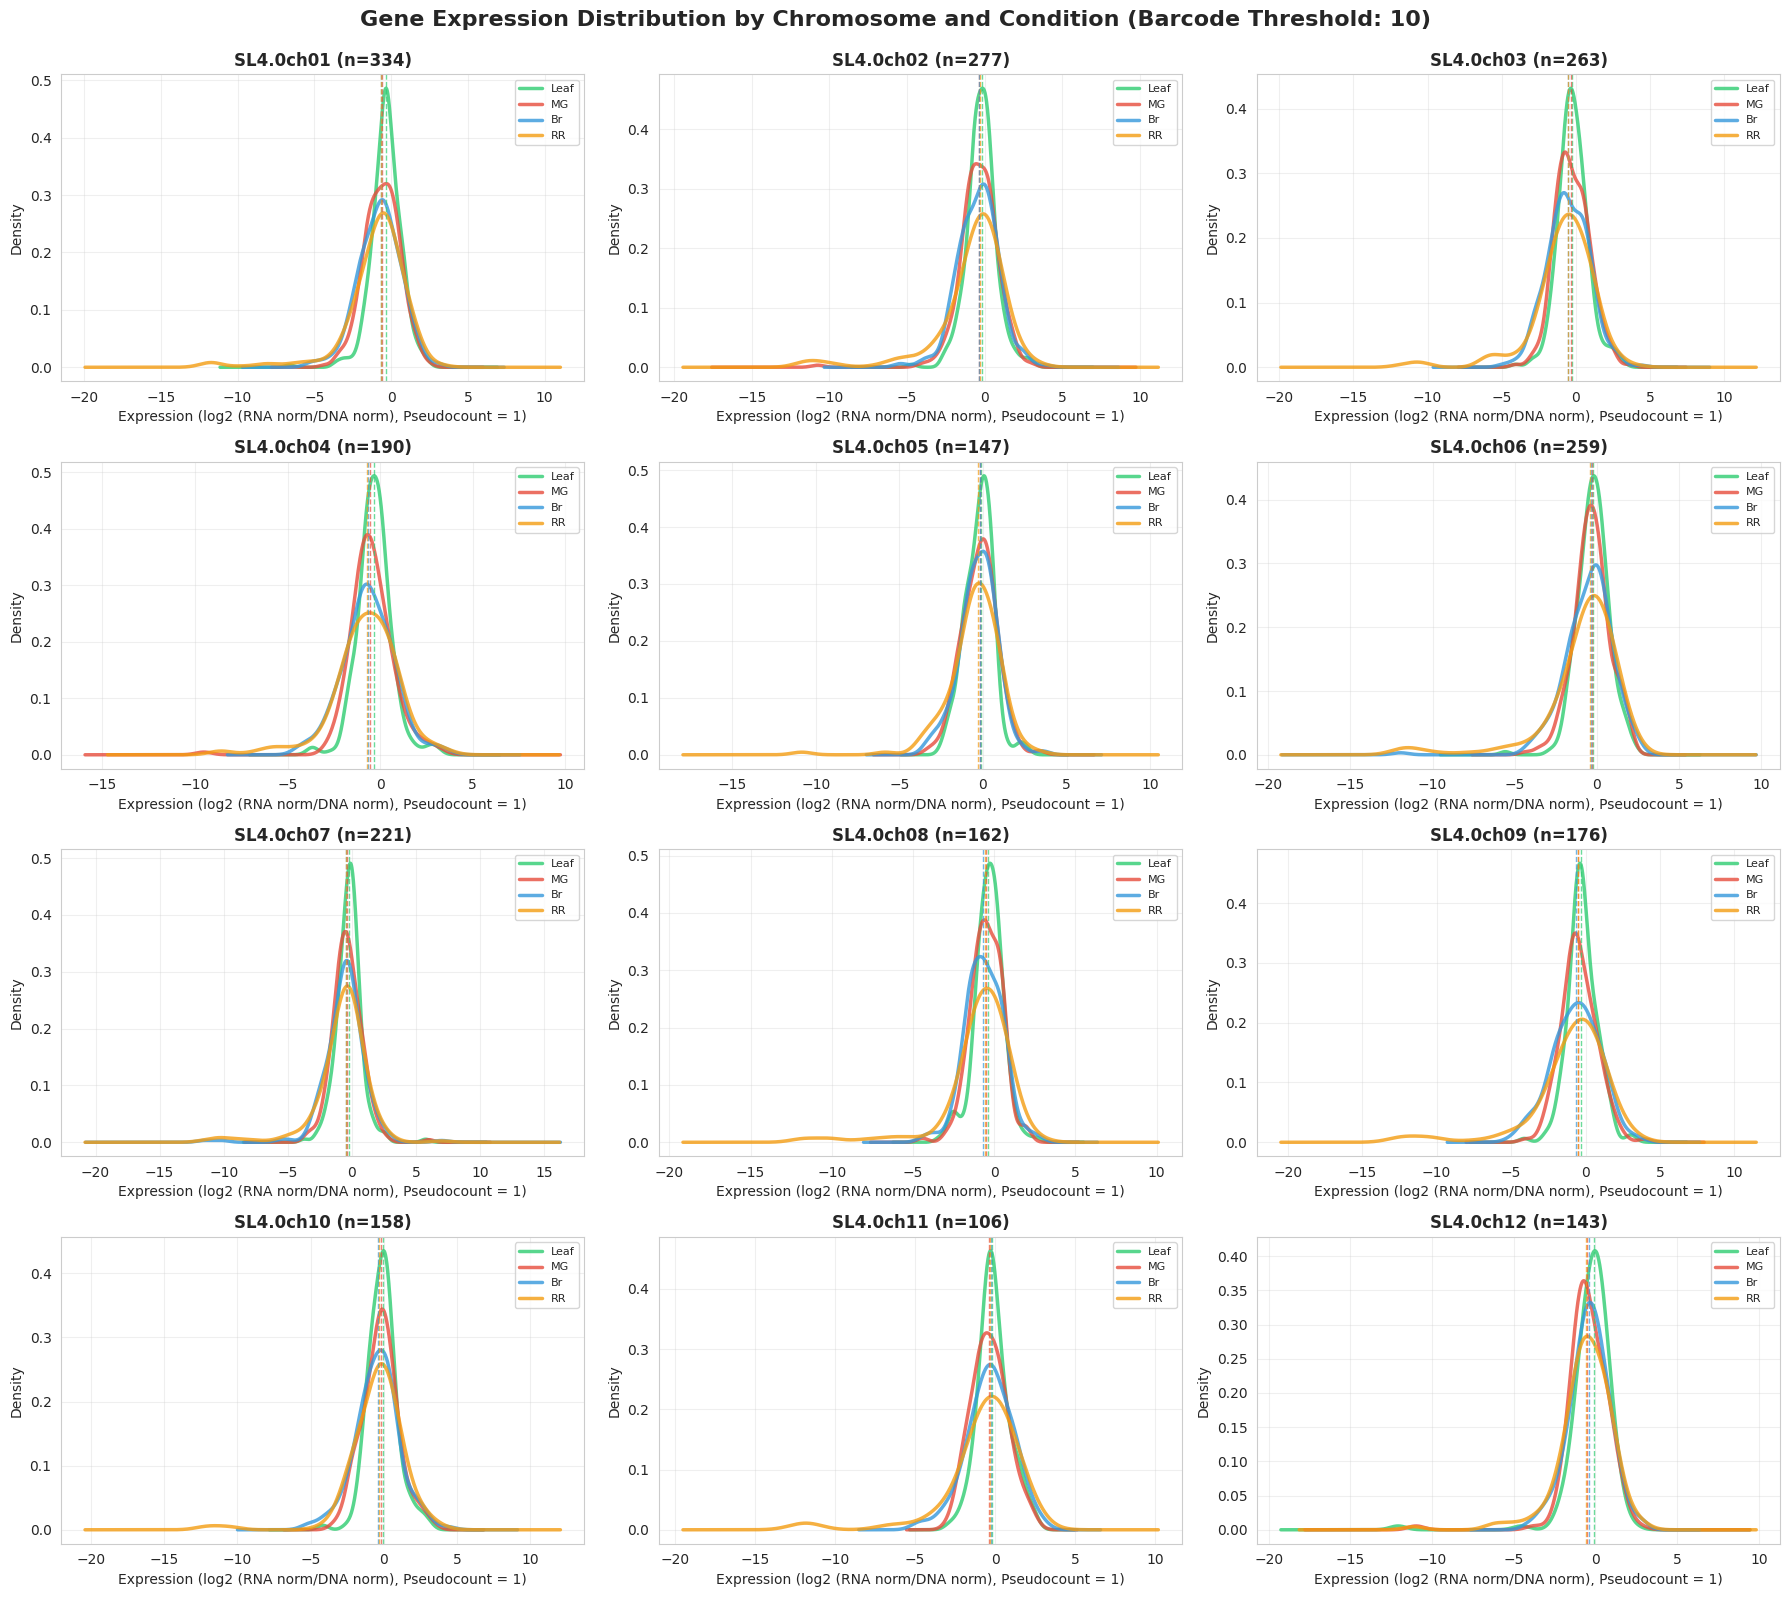

In [2]:
from data_prep import filter_threshold, split_chroms, plot__overall_distribution, plot_chrom_distributions
all_data = compute_pseudocount_log2_from_readcounts(full_readcount_file, sequences_file, metadata_path + "/full_pseudocount_log2.tsv", pseudocount=1)
barcode_threshold = 10
above_ten_thresh = filter_threshold(all_data, barcode_threshold) #start with >= 10 unique barcodes
chrom_dict, val_chrom, test_chrom, chrom_percentages = split_chroms(above_ten_thresh)

plot__overall_distribution(above_ten_thresh, barcode_threshold) #plot all the data
plot_chrom_distributions(chrom_dict, barcode_threshold)

In [3]:
from data_prep import compute_replicate_log2_activity, compute_replicate_correlations
compute_replicate_log2_activity(full_readcount_file, pseudocount=1)
compute_replicate_correlations(full_readcount_file, pseudocount=1, method='pearson')

Leaf: mean replicate correlation = 0.2172 (pairwise: {'1v2': np.float64(0.20777037970120624), '1v3': np.float64(0.22606139241204845), '2v3': np.float64(0.21775686084036025)})
MG: mean replicate correlation = 0.2745 (pairwise: {'1v2': np.float64(0.30149193240030625), '1v3': np.float64(0.266219648226526), '2v3': np.float64(0.2558111917989805)})
Br: mean replicate correlation = 0.3810 (pairwise: {'1v2': np.float64(0.5082433610964998), '1v3': np.float64(0.3178343077681081), '2v3': np.float64(0.3168419304939758)})
RR: mean replicate correlation = 0.4279 (pairwise: {'1v2': np.float64(0.4429174805571964), '1v3': np.float64(0.426127615558764), '2v3': np.float64(0.4146027667712498)})


{'Leaf': {'pairwise': {'1v2': np.float64(0.20777037970120624),
   '1v3': np.float64(0.22606139241204845),
   '2v3': np.float64(0.21775686084036025)},
  'mean': 0.2171962109845383},
 'MG': {'pairwise': {'1v2': np.float64(0.30149193240030625),
   '1v3': np.float64(0.266219648226526),
   '2v3': np.float64(0.2558111917989805)},
  'mean': 0.27450759080860426},
 'Br': {'pairwise': {'1v2': np.float64(0.5082433610964998),
   '1v3': np.float64(0.3178343077681081),
   '2v3': np.float64(0.3168419304939758)},
  'mean': 0.38097319978619454},
 'RR': {'pairwise': {'1v2': np.float64(0.4429174805571964),
   '1v3': np.float64(0.426127615558764),
   '2v3': np.float64(0.4146027667712498)},
  'mean': 0.42788262096240337}}

In [4]:
compute_replicate_correlations(full_readcount_file, pseudocount=1, method='pearson', min_barcodes=10)

Leaf: mean replicate correlation = 0.1897 (pairwise: {'1v2': np.float64(0.18779283130670543), '1v3': np.float64(0.20601966182095036), '2v3': np.float64(0.17528084380584433)})
MG: mean replicate correlation = 0.2497 (pairwise: {'1v2': np.float64(0.2620167209885857), '1v3': np.float64(0.26221006405995495), '2v3': np.float64(0.22475972776567194)})
Br: mean replicate correlation = 0.3870 (pairwise: {'1v2': np.float64(0.522068171250732), '1v3': np.float64(0.3008364105633719), '2v3': np.float64(0.3381999361986883)})
RR: mean replicate correlation = 0.3743 (pairwise: {'1v2': np.float64(0.3973877442699773), '1v3': np.float64(0.3555402347711868), '2v3': np.float64(0.3700149246060908)})


{'Leaf': {'pairwise': {'1v2': np.float64(0.18779283130670543),
   '1v3': np.float64(0.20601966182095036),
   '2v3': np.float64(0.17528084380584433)},
  'mean': 0.18969777897783335},
 'MG': {'pairwise': {'1v2': np.float64(0.2620167209885857),
   '1v3': np.float64(0.26221006405995495),
   '2v3': np.float64(0.22475972776567194)},
  'mean': 0.24966217093807086},
 'Br': {'pairwise': {'1v2': np.float64(0.522068171250732),
   '1v3': np.float64(0.3008364105633719),
   '2v3': np.float64(0.3381999361986883)},
  'mean': 0.38703483933759736},
 'RR': {'pairwise': {'1v2': np.float64(0.3973877442699773),
   '1v3': np.float64(0.3555402347711868),
   '2v3': np.float64(0.3700149246060908)},
  'mean': 0.37431430121575165}}

In [5]:
compute_replicate_correlations(full_readcount_file, pseudocount=1, method='pearson', min_barcodes=5)

Leaf: mean replicate correlation = 0.1463 (pairwise: {'1v2': np.float64(0.13958561126853633), '1v3': np.float64(0.17644366368867975), '2v3': np.float64(0.1227817746484275)})
MG: mean replicate correlation = 0.2366 (pairwise: {'1v2': np.float64(0.25684667439171177), '1v3': np.float64(0.22532815396493433), '2v3': np.float64(0.22760305634546207)})
Br: mean replicate correlation = 0.3527 (pairwise: {'1v2': np.float64(0.4622698364719926), '1v3': np.float64(0.2916627371553733), '2v3': np.float64(0.30409327653407475)})
RR: mean replicate correlation = 0.3921 (pairwise: {'1v2': np.float64(0.4066155661456437), '1v3': np.float64(0.3872251407983585), '2v3': np.float64(0.3824929199429457)})


{'Leaf': {'pairwise': {'1v2': np.float64(0.13958561126853633),
   '1v3': np.float64(0.17644366368867975),
   '2v3': np.float64(0.1227817746484275)},
  'mean': 0.14627034986854787},
 'MG': {'pairwise': {'1v2': np.float64(0.25684667439171177),
   '1v3': np.float64(0.22532815396493433),
   '2v3': np.float64(0.22760305634546207)},
  'mean': 0.23659262823403604},
 'Br': {'pairwise': {'1v2': np.float64(0.4622698364719926),
   '1v3': np.float64(0.2916627371553733),
   '2v3': np.float64(0.30409327653407475)},
  'mean': 0.3526752833871469},
 'RR': {'pairwise': {'1v2': np.float64(0.4066155661456437),
   '1v3': np.float64(0.3872251407983585),
   '2v3': np.float64(0.3824929199429457)},
  'mean': 0.392111208962316}}

In [6]:
compute_replicate_correlations(full_readcount_file, pseudocount=1, method='pearson', min_barcodes=10, spearman_brown=True)

Leaf: mean replicate correlation = 0.1897 (pairwise: {'1v2': np.float64(0.18779283130670543), '1v3': np.float64(0.20601966182095036), '2v3': np.float64(0.17528084380584433)}) | Spearman-Brown ceiling (n=3) = 0.4126
MG: mean replicate correlation = 0.2497 (pairwise: {'1v2': np.float64(0.2620167209885857), '1v3': np.float64(0.26221006405995495), '2v3': np.float64(0.22475972776567194)}) | Spearman-Brown ceiling (n=3) = 0.4997
Br: mean replicate correlation = 0.3870 (pairwise: {'1v2': np.float64(0.522068171250732), '1v3': np.float64(0.3008364105633719), '2v3': np.float64(0.3381999361986883)}) | Spearman-Brown ceiling (n=3) = 0.6590
RR: mean replicate correlation = 0.3743 (pairwise: {'1v2': np.float64(0.3973877442699773), '1v3': np.float64(0.3555402347711868), '2v3': np.float64(0.3700149246060908)}) | Spearman-Brown ceiling (n=3) = 0.6423


{'Leaf': {'pairwise': {'1v2': np.float64(0.18779283130670543),
   '1v3': np.float64(0.20601966182095036),
   '2v3': np.float64(0.17528084380584433)},
  'mean': 0.18969777897783335,
  'spearman_brown': 0.41261689463118617},
 'MG': {'pairwise': {'1v2': np.float64(0.2620167209885857),
   '1v3': np.float64(0.26221006405995495),
   '2v3': np.float64(0.22475972776567194)},
  'mean': 0.24966217093807086,
  'spearman_brown': 0.4996572643949444},
 'Br': {'pairwise': {'1v2': np.float64(0.522068171250732),
   '1v3': np.float64(0.3008364105633719),
   '2v3': np.float64(0.3381999361986883)},
  'mean': 0.38703483933759736,
  'spearman_brown': 0.6589782149699775},
 'RR': {'pairwise': {'1v2': np.float64(0.3973877442699773),
   '1v3': np.float64(0.3555402347711868),
   '2v3': np.float64(0.3700149246060908)},
  'mean': 0.37431430121575165,
  'spearman_brown': 0.6423147467706842}}

In [7]:
compute_replicate_correlations(full_readcount_file, pseudocount=1, method='pearson', min_barcodes=5, spearman_brown=True)

Leaf: mean replicate correlation = 0.1463 (pairwise: {'1v2': np.float64(0.13958561126853633), '1v3': np.float64(0.17644366368867975), '2v3': np.float64(0.1227817746484275)}) | Spearman-Brown ceiling (n=3) = 0.3396
MG: mean replicate correlation = 0.2366 (pairwise: {'1v2': np.float64(0.25684667439171177), '1v3': np.float64(0.22532815396493433), '2v3': np.float64(0.22760305634546207)}) | Spearman-Brown ceiling (n=3) = 0.4819
Br: mean replicate correlation = 0.3527 (pairwise: {'1v2': np.float64(0.4622698364719926), '1v3': np.float64(0.2916627371553733), '2v3': np.float64(0.30409327653407475)}) | Spearman-Brown ceiling (n=3) = 0.6231
RR: mean replicate correlation = 0.3921 (pairwise: {'1v2': np.float64(0.4066155661456437), '1v3': np.float64(0.3872251407983585), '2v3': np.float64(0.3824929199429457)}) | Spearman-Brown ceiling (n=3) = 0.6593


{'Leaf': {'pairwise': {'1v2': np.float64(0.13958561126853633),
   '1v3': np.float64(0.17644366368867975),
   '2v3': np.float64(0.1227817746484275)},
  'mean': 0.14627034986854787,
  'spearman_brown': 0.3396330123134259},
 'MG': {'pairwise': {'1v2': np.float64(0.25684667439171177),
   '1v3': np.float64(0.22532815396493433),
   '2v3': np.float64(0.22760305634546207)},
  'mean': 0.23659262823403604,
  'spearman_brown': 0.48187073522624224},
 'Br': {'pairwise': {'1v2': np.float64(0.4622698364719926),
   '1v3': np.float64(0.2916627371553733),
   '2v3': np.float64(0.30409327653407475)},
  'mean': 0.3526752833871469,
  'spearman_brown': 0.6231478642743695},
 'RR': {'pairwise': {'1v2': np.float64(0.4066155661456437),
   '1v3': np.float64(0.3872251407983585),
   '2v3': np.float64(0.3824929199429457)},
  'mean': 0.392111208962316,
  'spearman_brown': 0.6593456445907027}}

In [8]:
compute_replicate_correlations(full_readcount_file, pseudocount=1, method='pearson', min_barcodes=10, spearman_brown=True, include_pooled_fruit=True)

Leaf: mean replicate correlation = 0.1897 (pairwise: {'1v2': np.float64(0.18779283130670543), '1v3': np.float64(0.20601966182095036), '2v3': np.float64(0.17528084380584433)}) | Spearman-Brown ceiling (n=3) = 0.4126
MG: mean replicate correlation = 0.2497 (pairwise: {'1v2': np.float64(0.2620167209885857), '1v3': np.float64(0.26221006405995495), '2v3': np.float64(0.22475972776567194)}) | Spearman-Brown ceiling (n=3) = 0.4997
Br: mean replicate correlation = 0.3870 (pairwise: {'1v2': np.float64(0.522068171250732), '1v3': np.float64(0.3008364105633719), '2v3': np.float64(0.3381999361986883)}) | Spearman-Brown ceiling (n=3) = 0.6590
RR: mean replicate correlation = 0.3743 (pairwise: {'1v2': np.float64(0.3973877442699773), '1v3': np.float64(0.3555402347711868), '2v3': np.float64(0.3700149246060908)}) | Spearman-Brown ceiling (n=3) = 0.6423
Fruit: mean replicate correlation = 0.6176 (pairwise: {'1v2': np.float64(0.6529657350970858), '1v3': np.float64(0.578791596927668), '2v3': np.float64(0.62

{'Leaf': {'pairwise': {'1v2': np.float64(0.18779283130670543),
   '1v3': np.float64(0.20601966182095036),
   '2v3': np.float64(0.17528084380584433)},
  'mean': 0.18969777897783335,
  'spearman_brown': 0.41261689463118617},
 'MG': {'pairwise': {'1v2': np.float64(0.2620167209885857),
   '1v3': np.float64(0.26221006405995495),
   '2v3': np.float64(0.22475972776567194)},
  'mean': 0.24966217093807086,
  'spearman_brown': 0.4996572643949444},
 'Br': {'pairwise': {'1v2': np.float64(0.522068171250732),
   '1v3': np.float64(0.3008364105633719),
   '2v3': np.float64(0.3381999361986883)},
  'mean': 0.38703483933759736,
  'spearman_brown': 0.6589782149699775},
 'RR': {'pairwise': {'1v2': np.float64(0.3973877442699773),
   '1v3': np.float64(0.3555402347711868),
   '2v3': np.float64(0.3700149246060908)},
  'mean': 0.37431430121575165,
  'spearman_brown': 0.6423147467706842},
 'Fruit': {'pairwise': {'1v2': np.float64(0.6529657350970858),
   '1v3': np.float64(0.578791596927668),
   '2v3': np.float64(

In [9]:
compute_replicate_correlations(full_readcount_file, pseudocount=1, method='pearson', min_barcodes=5, spearman_brown=True, include_pooled_fruit=True)

Leaf: mean replicate correlation = 0.1463 (pairwise: {'1v2': np.float64(0.13958561126853633), '1v3': np.float64(0.17644366368867975), '2v3': np.float64(0.1227817746484275)}) | Spearman-Brown ceiling (n=3) = 0.3396
MG: mean replicate correlation = 0.2366 (pairwise: {'1v2': np.float64(0.25684667439171177), '1v3': np.float64(0.22532815396493433), '2v3': np.float64(0.22760305634546207)}) | Spearman-Brown ceiling (n=3) = 0.4819
Br: mean replicate correlation = 0.3527 (pairwise: {'1v2': np.float64(0.4622698364719926), '1v3': np.float64(0.2916627371553733), '2v3': np.float64(0.30409327653407475)}) | Spearman-Brown ceiling (n=3) = 0.6231
RR: mean replicate correlation = 0.3921 (pairwise: {'1v2': np.float64(0.4066155661456437), '1v3': np.float64(0.3872251407983585), '2v3': np.float64(0.3824929199429457)}) | Spearman-Brown ceiling (n=3) = 0.6593
Fruit: mean replicate correlation = 0.3895 (pairwise: {'1v2': np.float64(0.42154783637484156), '1v3': np.float64(0.3643393152142078), '2v3': np.float64(

{'Leaf': {'pairwise': {'1v2': np.float64(0.13958561126853633),
   '1v3': np.float64(0.17644366368867975),
   '2v3': np.float64(0.1227817746484275)},
  'mean': 0.14627034986854787,
  'spearman_brown': 0.3396330123134259},
 'MG': {'pairwise': {'1v2': np.float64(0.25684667439171177),
   '1v3': np.float64(0.22532815396493433),
   '2v3': np.float64(0.22760305634546207)},
  'mean': 0.23659262823403604,
  'spearman_brown': 0.48187073522624224},
 'Br': {'pairwise': {'1v2': np.float64(0.4622698364719926),
   '1v3': np.float64(0.2916627371553733),
   '2v3': np.float64(0.30409327653407475)},
  'mean': 0.3526752833871469,
  'spearman_brown': 0.6231478642743695},
 'RR': {'pairwise': {'1v2': np.float64(0.4066155661456437),
   '1v3': np.float64(0.3872251407983585),
   '2v3': np.float64(0.3824929199429457)},
  'mean': 0.392111208962316,
  'spearman_brown': 0.6593456445907027},
 'Fruit': {'pairwise': {'1v2': np.float64(0.42154783637484156),
   '1v3': np.float64(0.3643393152142078),
   '2v3': np.float64

Leaf: mean replicate correlation = 0.1463 (pairwise: {'1v2': np.float64(0.13958561126853633), '1v3': np.float64(0.17644366368867975), '2v3': np.float64(0.1227817746484275)}) | Spearman-Brown ceiling (n=3) = 0.3396
MG: mean replicate correlation = 0.2366 (pairwise: {'1v2': np.float64(0.25684667439171177), '1v3': np.float64(0.22532815396493433), '2v3': np.float64(0.22760305634546207)}) | Spearman-Brown ceiling (n=3) = 0.4819
Br: mean replicate correlation = 0.3527 (pairwise: {'1v2': np.float64(0.4622698364719926), '1v3': np.float64(0.2916627371553733), '2v3': np.float64(0.30409327653407475)}) | Spearman-Brown ceiling (n=3) = 0.6231
RR: mean replicate correlation = 0.3921 (pairwise: {'1v2': np.float64(0.4066155661456437), '1v3': np.float64(0.3872251407983585), '2v3': np.float64(0.3824929199429457)}) | Spearman-Brown ceiling (n=3) = 0.6593
Leaf: mean replicate correlation = 0.1897 (pairwise: {'1v2': np.float64(0.18779283130670543), '1v3': np.float64(0.20601966182095036), '2v3': np.float64(

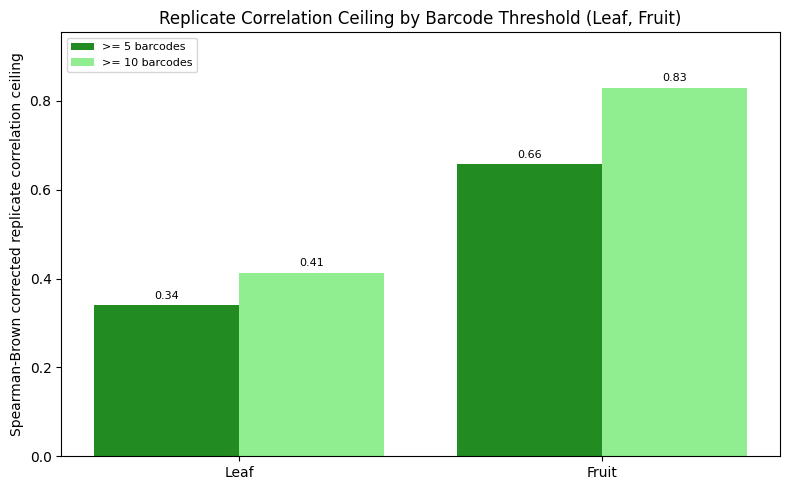

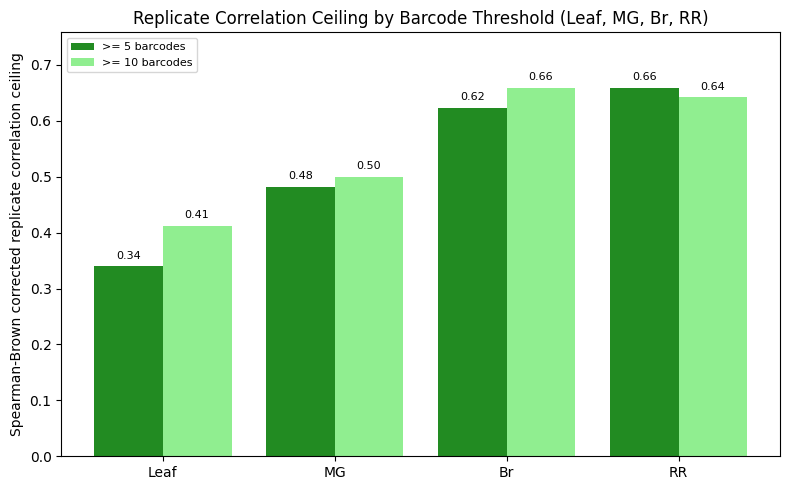

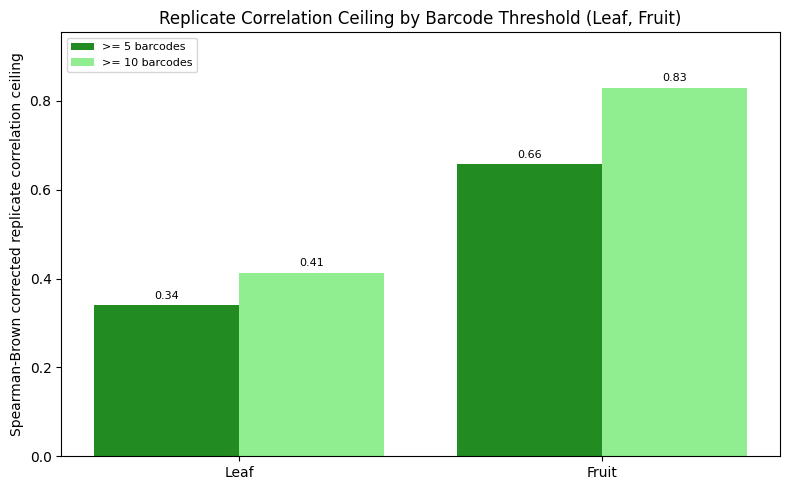

In [1]:
import sys
sys.path.insert(0, 'scripts/0_preprocess')
from data_prep import plot_replicate_ceiling_bar

plot_replicate_ceiling_bar(
    'metadata/RNA DNA ReadCount All.xlsx',
    states=['Leaf', 'MG', 'Br', 'RR'],
    thresholds=(5, 10),
    output_path='results/plots/replicate_ceiling_leaf_mg_br_rr.png',
)
plot_replicate_ceiling_bar(
    'metadata/RNA DNA ReadCount All.xlsx',
    states=['Leaf', 'Fruit'],
    thresholds=(5, 10),
    output_path='results/plots/replicate_ceiling_leaf_fruit.png',
)